<a href="https://colab.research.google.com/github/rogeralba19/orderbook/blob/main/Datos_order_book.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install python-binance

from binance.client import Client
import numpy as np
import time
from IPython.display import clear_output

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 65 kB 1.8 MB/s 
     |████████████████████████████████| 1.1 MB 40.3 MB/s 
     |████████████████████████████████| 288 kB 51.1 MB/s 
     |████████████████████████████████| 112 kB 43.3 MB/s 
     |████████████████████████████████| 45 kB 1.4 MB/s 
     |████████████████████████████████| 144 kB 49.2 MB/s 
     |████████████████████████████████| 94 kB 1.6 MB/s 
     |████████████████████████████████| 271 kB 45.4 MB/s 
     |████████████████████████████████| 749 kB 51.7 MB/s 
  Attempting uninstall: regex
    Found existing installation: regex 2022.6.2
    Uninstalling regex-2022.6.2:
      Successfully uninstalled regex-2022.6.2


In [ ]:
api_key="api_key"
api_secret="api_secret"
client = Client(api_key, api_secret)

In [ ]:
cont = 0
orderA = [] #Los datos donde se va a almacenar asks
orderB = [] #Los datos donde se va a almacenar bids
while cont < 300:
    print(cont)
    book = client.get_order_book(symbol="BTCUSDT", limit=50)
    book_asks = []
    book_bids = []
    book_asks.append(book['asks'])
    book_bids.append(book['bids'])

    datosA = np.reshape(book_asks, -1)
    datosB = np.reshape(book_bids, -1)

    orderA.append(datosA.tolist())
    orderB.append(datosB.tolist())
    cont = cont + 1
    time.sleep(1)
    clear_output(wait=True)

print(orderB)

[['19047.99000000', '0.24374000', '19047.55000000', '0.00057000', '19047.54000000', '0.30000000', '19045.05000000', '0.12357000', '19045.04000000', '0.00105000', '19045.03000000', '0.70056000', '19045.02000000', '0.00630000', '19044.75000000', '0.08542000', '19044.71000000', '0.31000000', '19044.20000000', '0.01890000', '19044.19000000', '0.00524000', '19043.25000000', '0.00208000', '19043.12000000', '0.28000000', '19042.77000000', '0.05454000', '19042.39000000', '0.08073000', '19041.55000000', '0.10000000', '19041.20000000', '0.28000000', '19040.75000000', '0.04697000', '19039.17000000', '0.68424000', '19039.15000000', '0.28000000', '19039.00000000', '1.00000000', '19038.90000000', '0.43050000', '19037.00000000', '0.42000000', '19036.98000000', '0.28000000', '19035.14000000', '2.75485000', '19035.05000000', '2.10000000', '19034.70000000', '0.00510000', '19034.69000000', '0.01400000', '19034.68000000', '0.28288000', '19034.58000000', '0.01574000', '19032.48000000', '7.36153000', '19032

In [ ]:
orderAa = []
orderBb = []
orderAa = np.reshape([orderA], (1,-1)).astype(float)
orderBb = np.reshape([orderB], (1,-1)).astype(float)

print(type(orderAa[0]))
#print(orderAa[0][0:2])

<class 'numpy.ndarray'>


<class 'numpy.ndarray'>


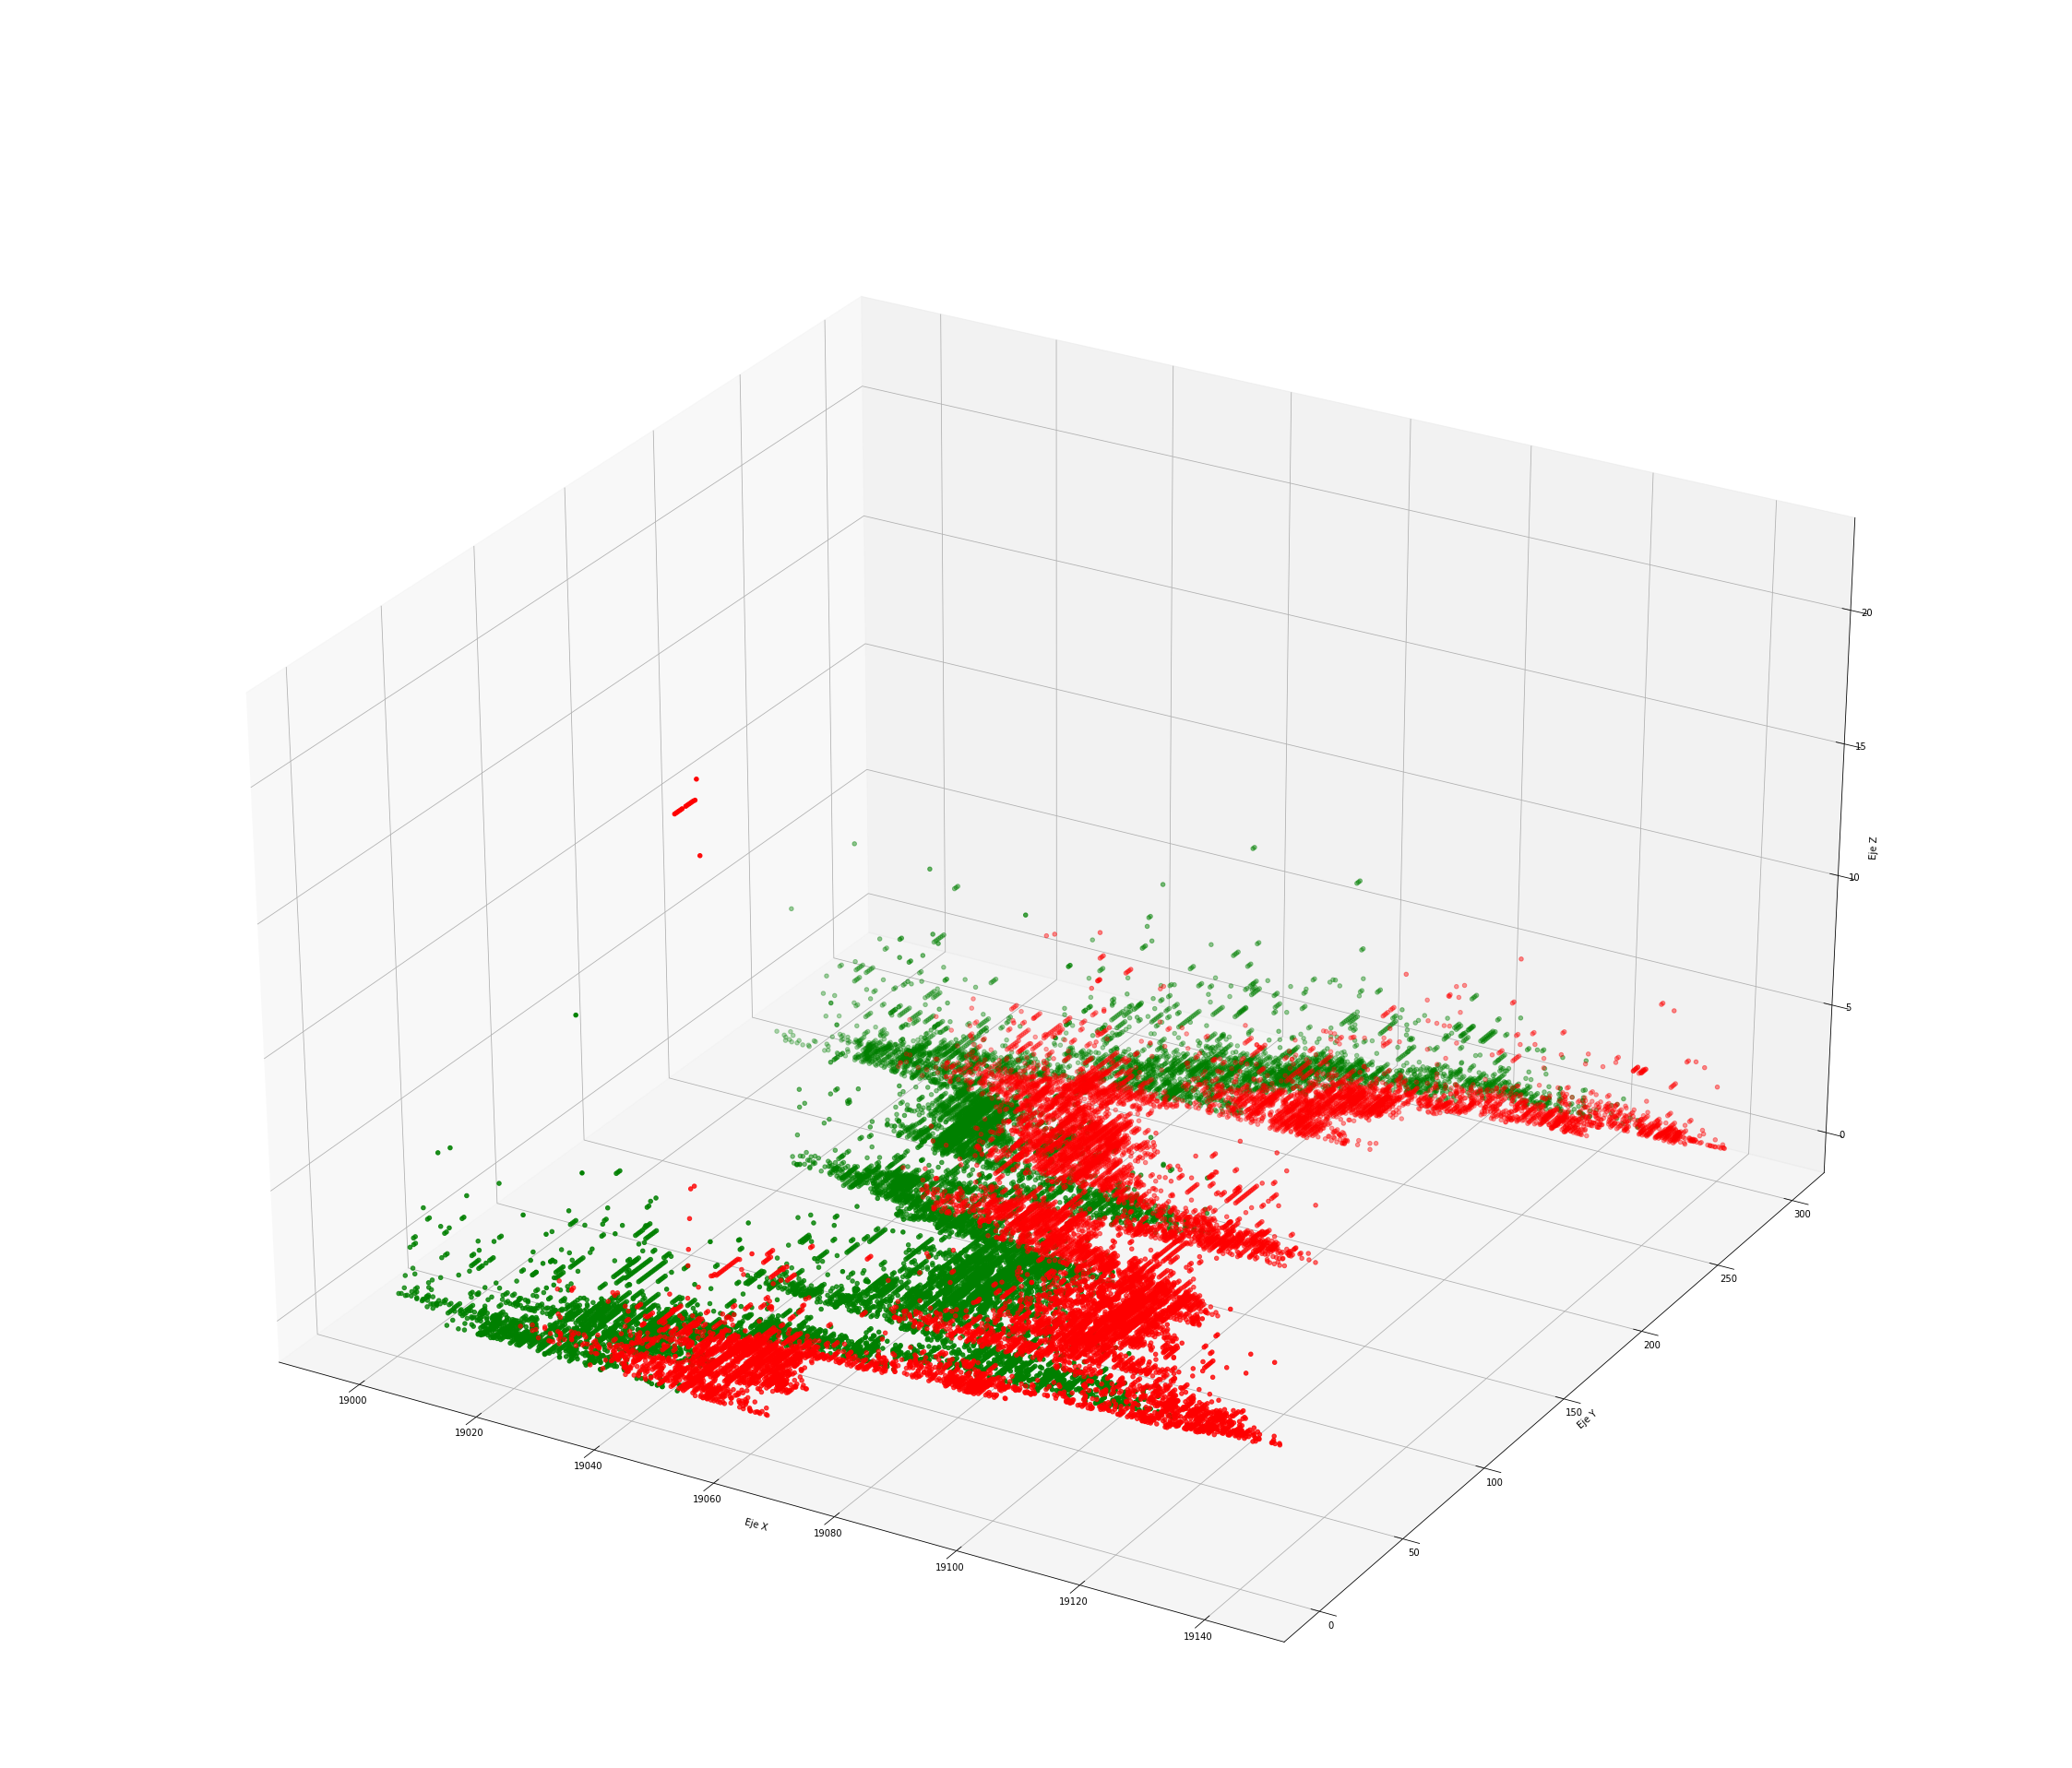

In [ ]:
# importamos las librerias necesarias
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
import matplotlib as mpl
import numpy as np
#import seaborn as sns

#sns.set(style = "whitegrid")
# Creamos la figura
fig = plt.figure(figsize=(40,35))
# Creamos el plano 3D
ax = fig.add_subplot(111, projection='3d')

y = np.array([])
for i in range(300):
  y = np.append(y, np.ones(50)+i)

# Definimos los datos de prueba
x1 = orderAa[0][0::2]
x2 = orderBb[0][0::2]

z1 = orderAa[0][1::2]
z2 = orderBb[0][1::2]
print(type(x1))
#print(len(y))
#print(len(z1))
# Datos adicionales
mpl.rcParams['legend.fontsize'] = 10

#fig = plt.figure(figsize=(20,15))
ax = fig.gca(projection='3d')


"""
Scaling is done from here...
"""
x_scale=32
y_scale=32
z_scale=25

scale=np.diag([x_scale, y_scale, z_scale, 1.0])
scale=scale*(1.0/scale.max())
scale[3,3]=1.0

def short_proj():
  return np.dot(Axes3D.get_proj(ax), scale)

ax.get_proj=short_proj
# Agregamos los puntos en el plano 3D
#ax1.scatter(x1, y, z1, c='g', marker='o')
#ax1.scatter(x2, y, z2, c='r', marker='^')

for c, m, xs, zs in [('r', 'o', x1, z1), ('g', 'o', x2, z2)]:
    ax.scatter(xs, y, zs, c=c, marker=m)

ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Eje Z')
# Mostramos el gráfico
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
from numpy.random import normal as normal
print('numpy: '+np.version.full_version)
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
import matplotlib
print('matplotlib: '+matplotlib.__version__)

numpy: 1.21.6
matplotlib: 3.2.2


In [ ]:
nfr = 30 # Number of frames
fps = 10 # Frame per sec
xs = []
ys = []
zs = []
ss = np.arange(1,nfr,0.5)
for s in ss:
    xs.append(normal(50,s,200))
    ys.append(normal(50,s,200))
    zs.append(normal(50,s,200))

<class 'list'>


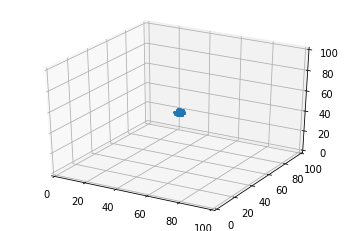

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
sct, = ax.plot([], [], [], "o", markersize=2)
def update(ifrm, xa, ya, za):
    sct.set_data(xa[ifrm], ya[ifrm])
    sct.set_3d_properties(za[ifrm])
ax.set_xlim(0,100)
ax.set_ylim(0,100)
ax.set_zlim(0,100)
ani = animation.FuncAnimation(fig, update, nfr, fargs=(xs,ys,zs), interval=1000/fps)
print(type(xs))

In [ ]:
fn = 'plot_3d_scatter_funcanimation'
ani.save(fn+'.mp4',writer='ffmpeg',fps=fps)
#ani.save(fn+'.gif',writer='imagemagick',fps=fps)